<a href="https://colab.research.google.com/github/swatikeshri-2005/AI-Journalist-Agent/blob/main/PCOS_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
data =pd.read_csv("PCOS_data.csv")

In [ ]:
data.head()

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.6,152.0,19.3,15,78,22,...,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,24.9,15,74,20,...,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,25.3,11,72,18,...,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN
3,4,4,0,37,65.0,148.0,29.7,13,72,20,...,0.0,0,120,70,2,2,15.0,14.0,7.5,NaN
4,5,5,0,25,52.0,161.0,20.1,11,72,18,...,0.0,0,120,80,3,4,16.0,14.0,7.0,NaN


In [ ]:
data.isnull()

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
536,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
537,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
538,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
539,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [ ]:
data.shape

(541, 45)

In [ ]:
data.columns

Index(['Sl. No', 'Patient File No.', 'PCOS (Y/N)', ' Age (yrs)', 'Weight (Kg)',
       'Height(Cm) ', 'BMI', 'Blood Group', 'Pulse rate(bpm) ',
       'RR (breaths/min)', 'Hb(g/dl)', 'Cycle(R/I)', 'Cycle length(days)',
       'Marraige Status (Yrs)', 'Pregnant(Y/N)', 'No. of abortions',
       '  I   beta-HCG(mIU/mL)', 'II    beta-HCG(mIU/mL)', 'FSH(mIU/mL)',
       'LH(mIU/mL)', 'FSH/LH', 'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio',
       'TSH (mIU/L)', 'AMH(ng/mL)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)',
       'PRG(ng/mL)', 'RBS(mg/dl)', 'Weight gain(Y/N)', 'hair growth(Y/N)',
       'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)',
       'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'BP _Systolic (mmHg)',
       'BP _Diastolic (mmHg)', 'Follicle No. (L)', 'Follicle No. (R)',
       'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)', 'Endometrium (mm)',
       'Unnamed: 44'],
      dtype='object')

In [ ]:
data.dtypes

,0
Sl. No,int64
Patient File No.,int64
PCOS (Y/N),int64
Age (yrs),int64
Weight (Kg),float64
Height(Cm),float64
BMI,float64
Blood Group,int64
Pulse rate(bpm),int64
RR (breaths/min),int64


In [ ]:
df = data.copy()

In [ ]:
df.drop(columns= ['Sl. No','Patient File No.','Marraige Status (Yrs)','Weight (Kg)','Height(Cm) ','Blood Group','II    beta-HCG(mIU/mL)', 'FSH(mIU/mL)',
       'LH(mIU/mL)', 'Hip(inch)', 'Waist(inch)','TSH (mIU/L)','Endometrium (mm)','Unnamed: 44'], axis=1, inplace= True)

In [ ]:
df.drop(columns=['RR (breaths/min)','BP _Systolic (mmHg)','BP _Diastolic (mmHg)' ],axis=1, inplace= True)

In [ ]:
df.rename(columns={'Pulse rate(bpm) ':'PR'}, inplace= True)

In [ ]:
df.drop(columns= ['PR'], axis=1, inplace= True)

In [ ]:
df['Average Fallopian Tube Size']= df['Avg. F size (L) (mm)'] + df['Avg. F size (R) (mm)']/2

In [ ]:
df['Total Follicles'] = df['Follicle No. (L)'] + df['Follicle No. (R)']

In [ ]:
df.drop(columns=['Follicle No. (L)', 'Follicle No. (R)','Avg. F size (L) (mm)', 'Avg. F size (R) (mm)'],axis=1, inplace= True)

In [ ]:
df.shape

(541, 25)

In [ ]:
df.isnull().sum()

,0
PCOS (Y/N),0
Age (yrs),0
BMI,0
Hb(g/dl),0
Cycle(R/I),0
Cycle length(days),0
Pregnant(Y/N),0
No. of abortions,0
I beta-HCG(mIU/mL),0
FSH/LH,0


In [ ]:
df['Fast food (Y/N)'].value_counts()

,count
Fast food (Y/N),
1.0,278
0.0,262


In [ ]:
df['Fast food (Y/N)'].fillna(1, inplace=True)

In [ ]:
df.shape

(541, 25)

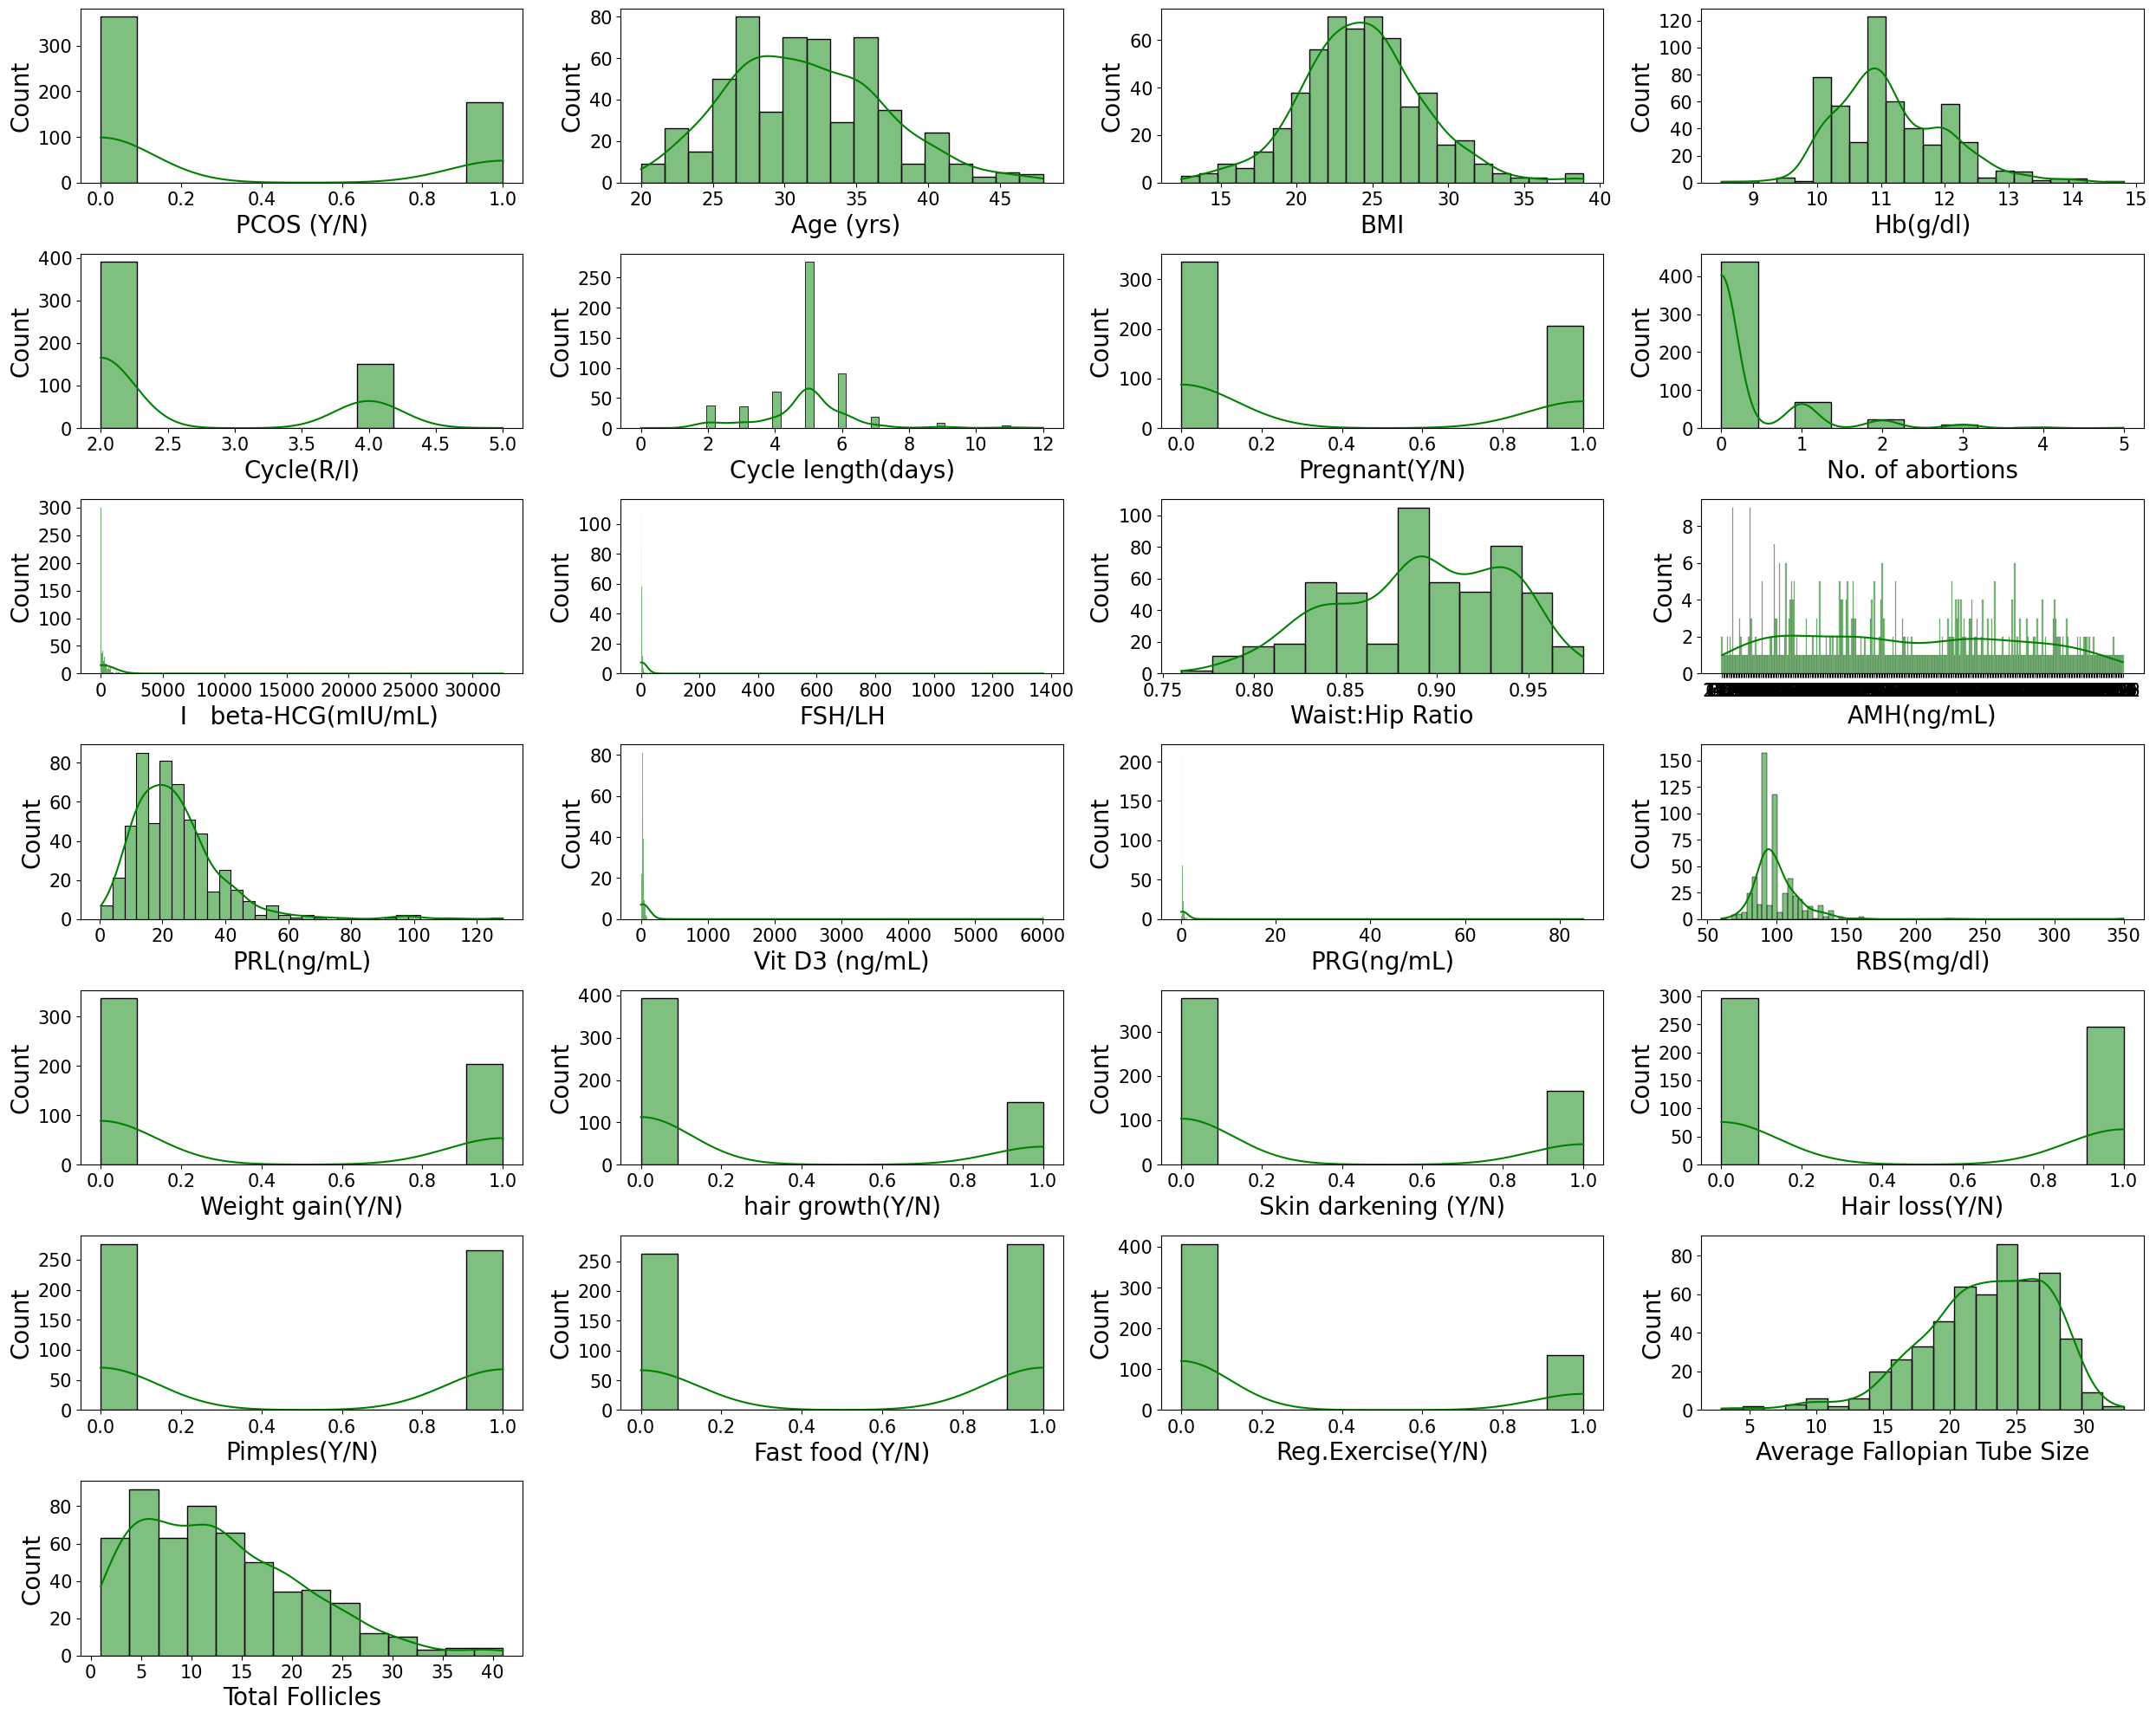

In [ ]:
plt.figure(figsize=(25, 25), facecolor='white')
plot_num = 1
num_cols = min(len(df.columns), 25)  # Ensure we don't exceed the number of columns in df
num_rows = (num_cols - 1) // 3 + 1  # 3 columns per row and # Adjusting the subplot layout to fit 29 plots

for column in df.columns:
    if plot_num <= num_cols:
        plt.subplot(num_rows, 4, plot_num)  # Adjust the subplot layout dynamically
        sns.histplot(df[column], color="green", kde=True)
        plt.xlabel(column, fontsize=20)
        plt.ylabel('Count', fontsize=20)  # Assuming ylabel is 'Count' for all
        plt.xticks(fontsize=15)
        plt.yticks(fontsize=15)
    plot_num += 1

plt.tight_layout()
plt.show()

In [ ]:
df1 = df.copy()

In [ ]:
df1.columns

Index(['PCOS (Y/N)', ' Age (yrs)', 'BMI', 'Hb(g/dl)', 'Cycle(R/I)',
       'Cycle length(days)', 'Pregnant(Y/N)', 'No. of abortions',
       '  I   beta-HCG(mIU/mL)', 'FSH/LH', 'Waist:Hip Ratio', 'AMH(ng/mL)',
       'PRL(ng/mL)', 'Vit D3 (ng/mL)', 'PRG(ng/mL)', 'RBS(mg/dl)',
       'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)',
       'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)',
       'Reg.Exercise(Y/N)', 'Average Fallopian Tube Size', 'Total Follicles'],
      dtype='object')

In [ ]:
def BMI_Range(BMI):
    if BMI >=30.0:
        return 'Obesity'
    elif BMI >= 25.0:
        return 'Overweight'
    elif BMI >18.5:
        return 'Normal_Weight'
    else:
        return 'Under_Weight'

In [ ]:
df1['BMI_Range'] = df1['BMI'].apply(BMI_Range)

In [ ]:
def Cycle_Severity(cycle):
    if cycle ==5:
        return 'More_Severe'
    elif cycle ==4:
        return 'Moderate'
    else:
        return 'Less_Severe'

In [ ]:
df1['Cycle_Severity']= df1['Cycle(R/I)'].apply(Cycle_Severity)

In [ ]:
def follicle_range (tf):
    if tf>24:
        return 'High_count'
    elif tf>16:
        return 'Normal_count'
    else:
        return 'Low_count'

In [ ]:
df1['Follicle_range']= df1['Total Follicles'].apply(follicle_range)

In [ ]:
def waist_hip (wh):
    if wh<0.80:
        return 'Low_risk'
    elif wh<0.85:
        return 'Moderate_risk'
    else:
        return 'High_risk'


In [ ]:
df1['Waist_hip_ratio']= df1['Waist:Hip Ratio'].apply(waist_hip)

In [ ]:
df1['AMH(ng/mL)'] = pd.to_numeric(df1['AMH(ng/mL)'], errors='coerce')

In [ ]:
def AMH (amh): ##Anti-Mullerian Hormone Test
    if amh>4.0:
        return 'High_AMH'
    elif amh>1.0:
        return 'Normal_AMH'
    else:
        return 'Low_AMH'

In [ ]:
df1['AMH_Range']= df1['AMH(ng/mL)'].apply(AMH)

In [ ]:
df1.columns

Index(['PCOS (Y/N)', ' Age (yrs)', 'BMI', 'Hb(g/dl)', 'Cycle(R/I)',
       'Cycle length(days)', 'Pregnant(Y/N)', 'No. of abortions',
       '  I   beta-HCG(mIU/mL)', 'FSH/LH', 'Waist:Hip Ratio', 'AMH(ng/mL)',
       'PRL(ng/mL)', 'Vit D3 (ng/mL)', 'PRG(ng/mL)', 'RBS(mg/dl)',
       'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)',
       'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)',
       'Reg.Exercise(Y/N)', 'Average Fallopian Tube Size', 'Total Follicles',
       'BMI_Range', 'Cycle_Severity', 'Follicle_range', 'Waist_hip_ratio',
       'AMH_Range'],
      dtype='object')

In [ ]:
df1.groupby(df1['PCOS (Y/N)']).count()

,Age (yrs),BMI,Hb(g/dl),Cycle(R/I),Cycle length(days),Pregnant(Y/N),No. of abortions,I beta-HCG(mIU/mL),FSH/LH,Waist:Hip Ratio,...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),Average Fallopian Tube Size,Total Follicles,BMI_Range,Cycle_Severity,Follicle_range,Waist_hip_ratio,AMH_Range
PCOS (Y/N),,,,,,,,,,,,,,,,,,,,,
0,364,364,364,364,364,364,364,364,364,364,...,364,364,364,364,364,364,364,364,364,364
1,177,177,177,177,177,177,177,177,177,177,...,177,177,177,177,177,177,177,177,177,177


In [ ]:
df1.groupby(df1['PCOS (Y/N)']).min('Age (yrs)')

,Age (yrs),BMI,Hb(g/dl),Cycle(R/I),Cycle length(days),Pregnant(Y/N),No. of abortions,I beta-HCG(mIU/mL),FSH/LH,Waist:Hip Ratio,...,RBS(mg/dl),Weight gain(Y/N),hair growth(Y/N),Skin darkening (Y/N),Hair loss(Y/N),Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),Average Fallopian Tube Size,Total Follicles
PCOS (Y/N),,,,,,,,,,,,,,,,,,,,,
0,20,13.4,8.5,2,0,0,0,1.30,0.23,0.78,...,60.0,0,0,0,0,0,0.0,0,2.90,1
1,21,12.4,9.4,2,2,0,0,1.92,0.00,0.76,...,70.0,0,0,0,0,0,0.0,0,9.25,2


In [ ]:
PCOS1= df1.loc[df1['PCOS (Y/N)']==1]

In [ ]:
PCOS1.loc[PCOS1['No. of abortions']== 0]

,PCOS (Y/N),Age (yrs),BMI,Hb(g/dl),Cycle(R/I),Cycle length(days),Pregnant(Y/N),No. of abortions,I beta-HCG(mIU/mL),FSH/LH,...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),Average Fallopian Tube Size,Total Follicles,BMI_Range,Cycle_Severity,Follicle_range,Waist_hip_ratio,AMH_Range
2,1,33,25.3,11.8,2,5,1,0,494.08,6.30,...,1,1.0,0,28.0,28,Overweight,Less_Severe,High_count,High_risk,High_AMH
12,1,25,32.0,11.7,4,2,1,0,1214.23,1.32,...,1,1.0,1,30.5,23,Obesity,Moderate,Normal_count,High_risk,High_AMH
19,1,30,31.2,12.5,4,7,0,0,23.58,2.33,...,1,1.0,0,26.5,24,Obesity,Moderate,Normal_count,High_risk,Normal_AMH
24,1,34,25.2,11.2,2,5,1,0,610.63,6.00,...,1,1.0,0,26.5,10,Overweight,Less_Severe,Low_count,Moderate_risk,Normal_AMH
26,1,30,29.7,11.2,4,3,0,0,1.99,2.22,...,1,1.0,1,17.0,41,Overweight,Moderate,High_count,Moderate_risk,Normal_AMH
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,1,23,26.4,10.6,5,7,0,0,121.05,3.74,...,0,1.0,0,25.0,18,Overweight,More_Severe,Normal_count,High_risk,High_AMH
520,1,27,17.7,12.0,4,2,0,0,632.22,2.11,...,1,0.0,0,29.5,38,Under_Weight,Moderate,High_count,High_risk,High_AMH
523,1,36,26.7,10.2,4,7,0,0,2.14,5.71,...,1,0.0,0,28.0,15,Overweight,Moderate,Low_count,High_risk,High_AMH
533,1,26,20.5,10.6,4,7,0,0,572.86,0.80,...,1,0.0,0,27.0,18,Normal_Weight,Moderate,Normal_count,High_risk,High_AMH


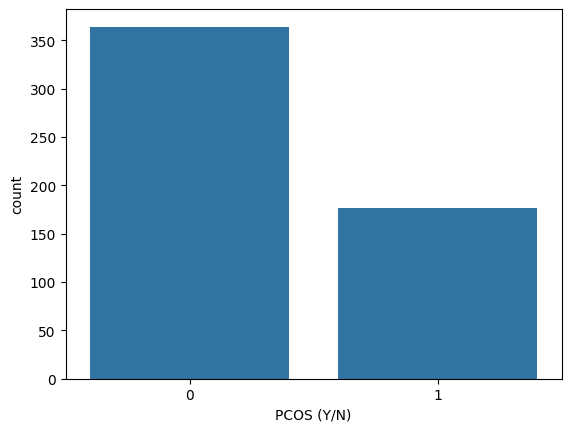

In [ ]:
sns.countplot(x='PCOS (Y/N)', data=df)
plt.show()

<Axes: xlabel='Fast food (Y/N)', ylabel='count'>

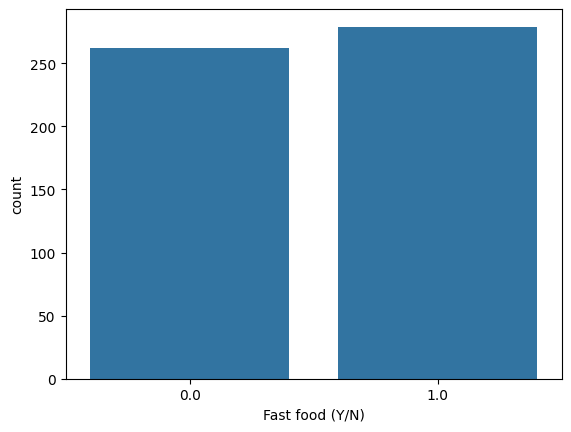

In [ ]:
sns.countplot(x='Fast food (Y/N)', data=df)

<Axes: xlabel='Weight gain(Y/N)', ylabel='count'>

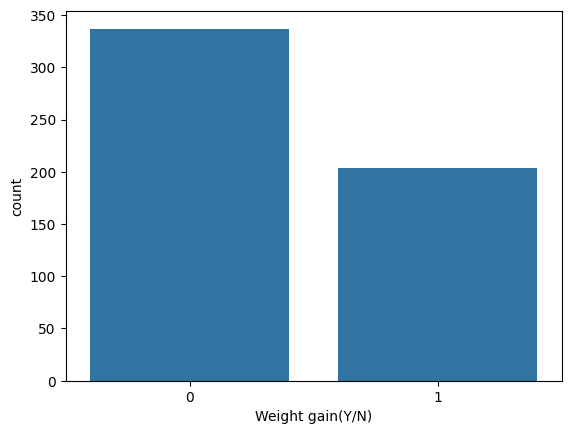

In [ ]:
sns.countplot(x='Weight gain(Y/N)', data=df)

<Axes: xlabel='hair growth(Y/N)', ylabel='count'>

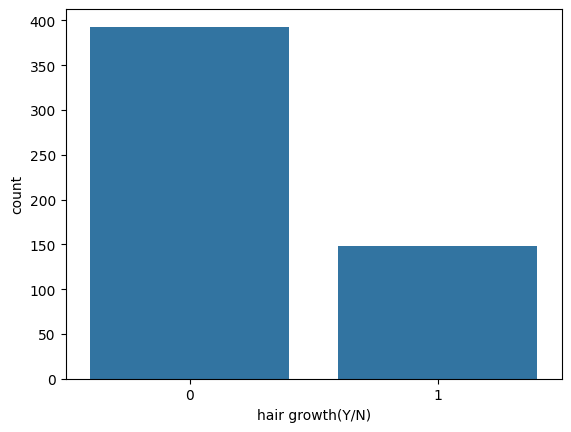

In [ ]:
sns.countplot(x='hair growth(Y/N)', data=df)

<Axes: xlabel='Hair loss(Y/N)', ylabel='count'>

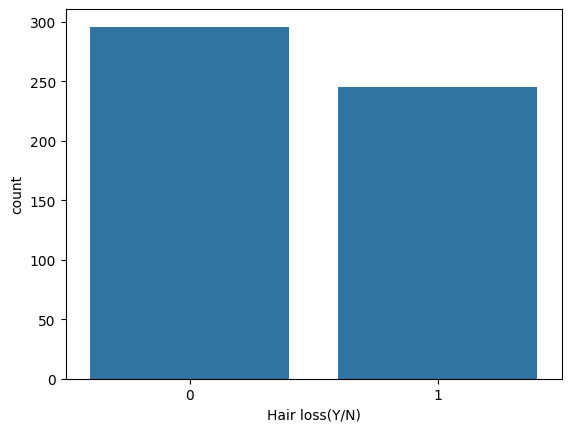

In [ ]:
sns.countplot(x='Hair loss(Y/N)', data=df)

<Axes: xlabel='Skin darkening (Y/N)', ylabel='count'>

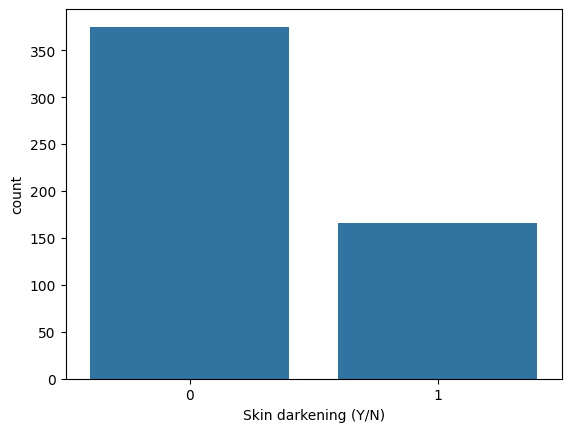

In [ ]:
sns.countplot(x='Skin darkening (Y/N)', data=df)

<Axes: xlabel='Pimples(Y/N)', ylabel='count'>

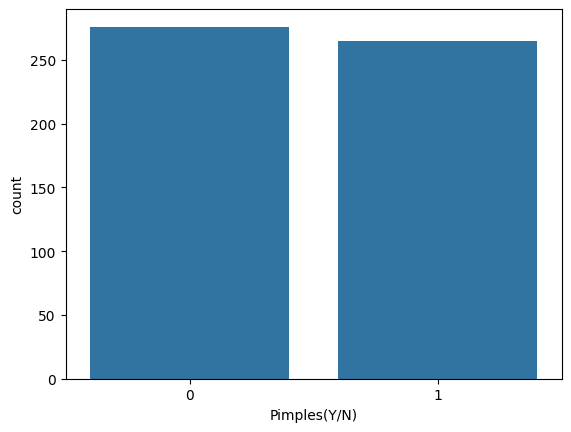

In [ ]:
sns.countplot(x='Pimples(Y/N)', data=df)

<Axes: xlabel='Reg.Exercise(Y/N)', ylabel='count'>

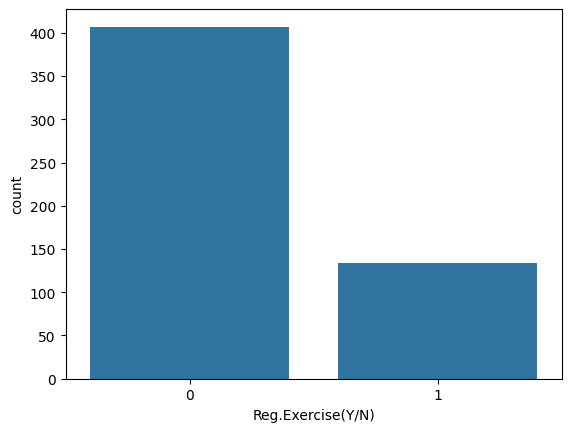

In [ ]:
sns.countplot(x='Reg.Exercise(Y/N)', data=df)

<Axes: xlabel='BMI', ylabel='Count'>

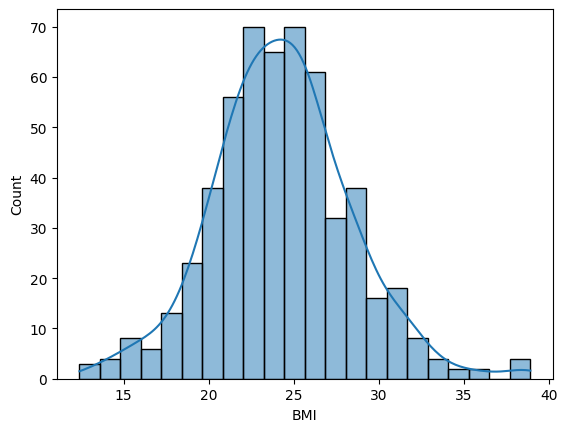

In [ ]:
sns.histplot(x='BMI', data=df, kde= True)

<Axes: xlabel='BMI'>

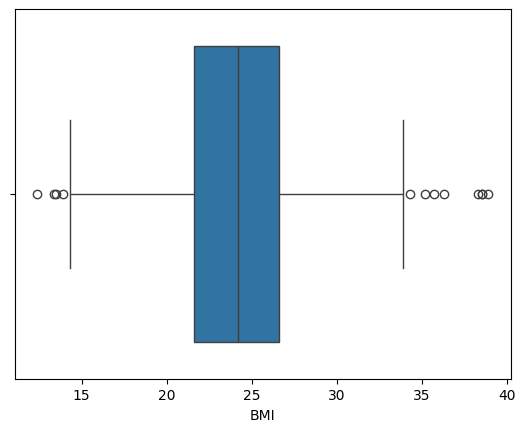

In [ ]:
sns.boxplot(x='BMI', data=df)

In [ ]:
df['BMI'].describe()

,BMI
count,541.000000
mean,24.307579
std,4.055129
min,12.400000
25%,21.600000
50%,24.200000
75%,26.600000
max,38.900000


In [ ]:
IQR = 26.6-21.6 #Q3-Q1
IQR

5.0

In [ ]:
L = 21.6- 1.5*5.0 # Lower Bound: Q1-1.5(IQR)
L

14.100000000000001

In [ ]:
U = 26.6 + 1.5*5.0
U

34.1

In [ ]:
df.loc[(df['BMI']<14.1) & (df['BMI']>34.1),'BMI']= np.mean(df.BMI)

In [ ]:
selected_columns = ['Weight gain(Y/N)', 'hair growth(Y/N)','Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)','Fast food (Y/N)', 'Reg.Exercise(Y/N)','BMI','PCOS (Y/N)']

In [ ]:
df1_selected = df[selected_columns]

In [ ]:
df1_selected.head()

,Weight gain(Y/N),hair growth(Y/N),Skin darkening (Y/N),Hair loss(Y/N),Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BMI,PCOS (Y/N)
0,0,0,0,0,0,1.0,0,19.3,0
1,0,0,0,0,0,0.0,0,24.9,0
2,0,0,0,1,1,1.0,0,25.3,1
3,0,0,0,0,0,0.0,0,29.7,0
4,0,0,0,1,0,0.0,0,20.1,0


In [ ]:
df1_selected [['Fast food (Y/N)','BMI']]=df1_selected [['Fast food (Y/N)','BMI']].astype('int64')

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
scaler = MinMaxScaler()

In [ ]:
df1_selected['BMI']= scaler.fit_transform (df1_selected[['BMI']])

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x1 = df1_selected.drop("PCOS (Y/N)",axis=1)
y1 = df1_selected["PCOS (Y/N)"]

In [ ]:
x1_train,x1_test,y1_train,y1_test= train_test_split(x1,y1,test_size=0.2,random_state= 40)

In [ ]:
LR = LogisticRegression()

In [ ]:
LR.fit(x1_train, y1_train)

LogisticRegression()

In [ ]:
LR.score(x1,y1)

0.8465804066543438

In [ ]:
y1_predict= LR.predict(x1_test)

In [ ]:
y1_predict

array([0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0])

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score,classification_report

In [ ]:
accuracy = accuracy_score(y1_test,y1_predict)
accuracy

0.8623853211009175

In [ ]:
precision = precision_score(y1_test, y1_predict)
precision

0.8181818181818182

In [ ]:
recall = recall_score(y1_test, y1_predict)
recall

0.75

In [ ]:
f1 = f1_score(y1_test,y1_predict)
f1

0.782608695652174

In [ ]:
confusion = confusion_matrix(y1_test,y1_predict)
confusion

array([[67,  6],
       [ 9, 27]])

In [ ]:
roc_auc = roc_auc_score(y1_test,y1_predict)
roc_auc

np.float64(0.8339041095890412)

In [ ]:
classification = classification_report(y1_test,y1_predict)
print(classification)

              precision    recall  f1-score   support

           0       0.88      0.92      0.90        73
           1       0.82      0.75      0.78        36

    accuracy                           0.86       109
   macro avg       0.85      0.83      0.84       109
weighted avg       0.86      0.86      0.86       109



In [ ]:
selected_test= ['Hb(g/dl)', 'Cycle(R/I)', 'Cycle length(days)','Pregnant(Y/N)', 'No. of abortions', '  I   beta-HCG(mIU/mL)', 'FSH/LH','Waist:Hip Ratio', 'AMH(ng/mL)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)','PRG(ng/mL)', 'RBS(mg/dl)', 'Average Fallopian Tube Size','PCOS (Y/N)']

In [ ]:
df2 = df[selected_test]

In [ ]:
df2.head()

,Hb(g/dl),Cycle(R/I),Cycle length(days),Pregnant(Y/N),No. of abortions,I beta-HCG(mIU/mL),FSH/LH,Waist:Hip Ratio,AMH(ng/mL),PRL(ng/mL),Vit D3 (ng/mL),PRG(ng/mL),RBS(mg/dl),Average Fallopian Tube Size,PCOS (Y/N)
0,10.48,2,5,0,0,1.99,2.16,0.83,2.07,45.16,17.1,0.57,92.0,27.0,0
1,11.70,2,5,1,0,60.80,6.17,0.84,1.53,20.09,61.3,0.97,92.0,22.0,0
2,11.80,2,5,1,0,494.08,6.30,0.90,6.63,10.52,49.7,0.36,84.0,28.0,1
3,12.00,2,5,0,0,1.99,3.42,0.86,1.22,36.90,33.4,0.36,76.0,22.0,0
4,10.00,2,5,1,0,801.45,4.42,0.81,2.26,30.09,43.8,0.38,84.0,23.0,0


In [ ]:
last_column = df2.columns[-1]

In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
for column in df2:
    if df2.dtypes[column]=='object' and column != last_column:
        df2[column] = label_encoder.fit_transform(df2[column])

In [ ]:
df2

,Hb(g/dl),Cycle(R/I),Cycle length(days),Pregnant(Y/N),No. of abortions,I beta-HCG(mIU/mL),FSH/LH,Waist:Hip Ratio,AMH(ng/mL),PRL(ng/mL),Vit D3 (ng/mL),PRG(ng/mL),RBS(mg/dl),Average Fallopian Tube Size,PCOS (Y/N)
0,10.48,2,5,0,0,1.99,2.16,0.83,124,45.16,17.1,0.57,92.0,27.0,0
1,11.70,2,5,1,0,60.80,6.17,0.84,49,20.09,61.3,0.97,92.0,22.0,0
2,11.80,2,5,1,0,494.08,6.30,0.90,266,10.52,49.7,0.36,84.0,28.0,1
3,12.00,2,5,0,0,1.99,3.42,0.86,41,36.90,33.4,0.36,76.0,22.0,0
4,10.00,2,5,1,0,801.45,4.42,0.81,133,30.09,43.8,0.38,84.0,23.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
536,11.00,2,5,0,1,1.99,5.56,0.93,59,5.30,36.6,0.25,92.0,22.5,0
537,10.80,2,5,1,1,80.13,1.79,0.94,243,21.09,23.0,0.25,108.0,28.0,0
538,10.80,2,6,0,0,1.99,4.30,0.93,198,96.41,22.5,0.25,92.0,22.5,0
539,12.00,4,2,0,0,292.92,1.02,0.93,234,38.89,22.4,0.25,115.0,26.0,0


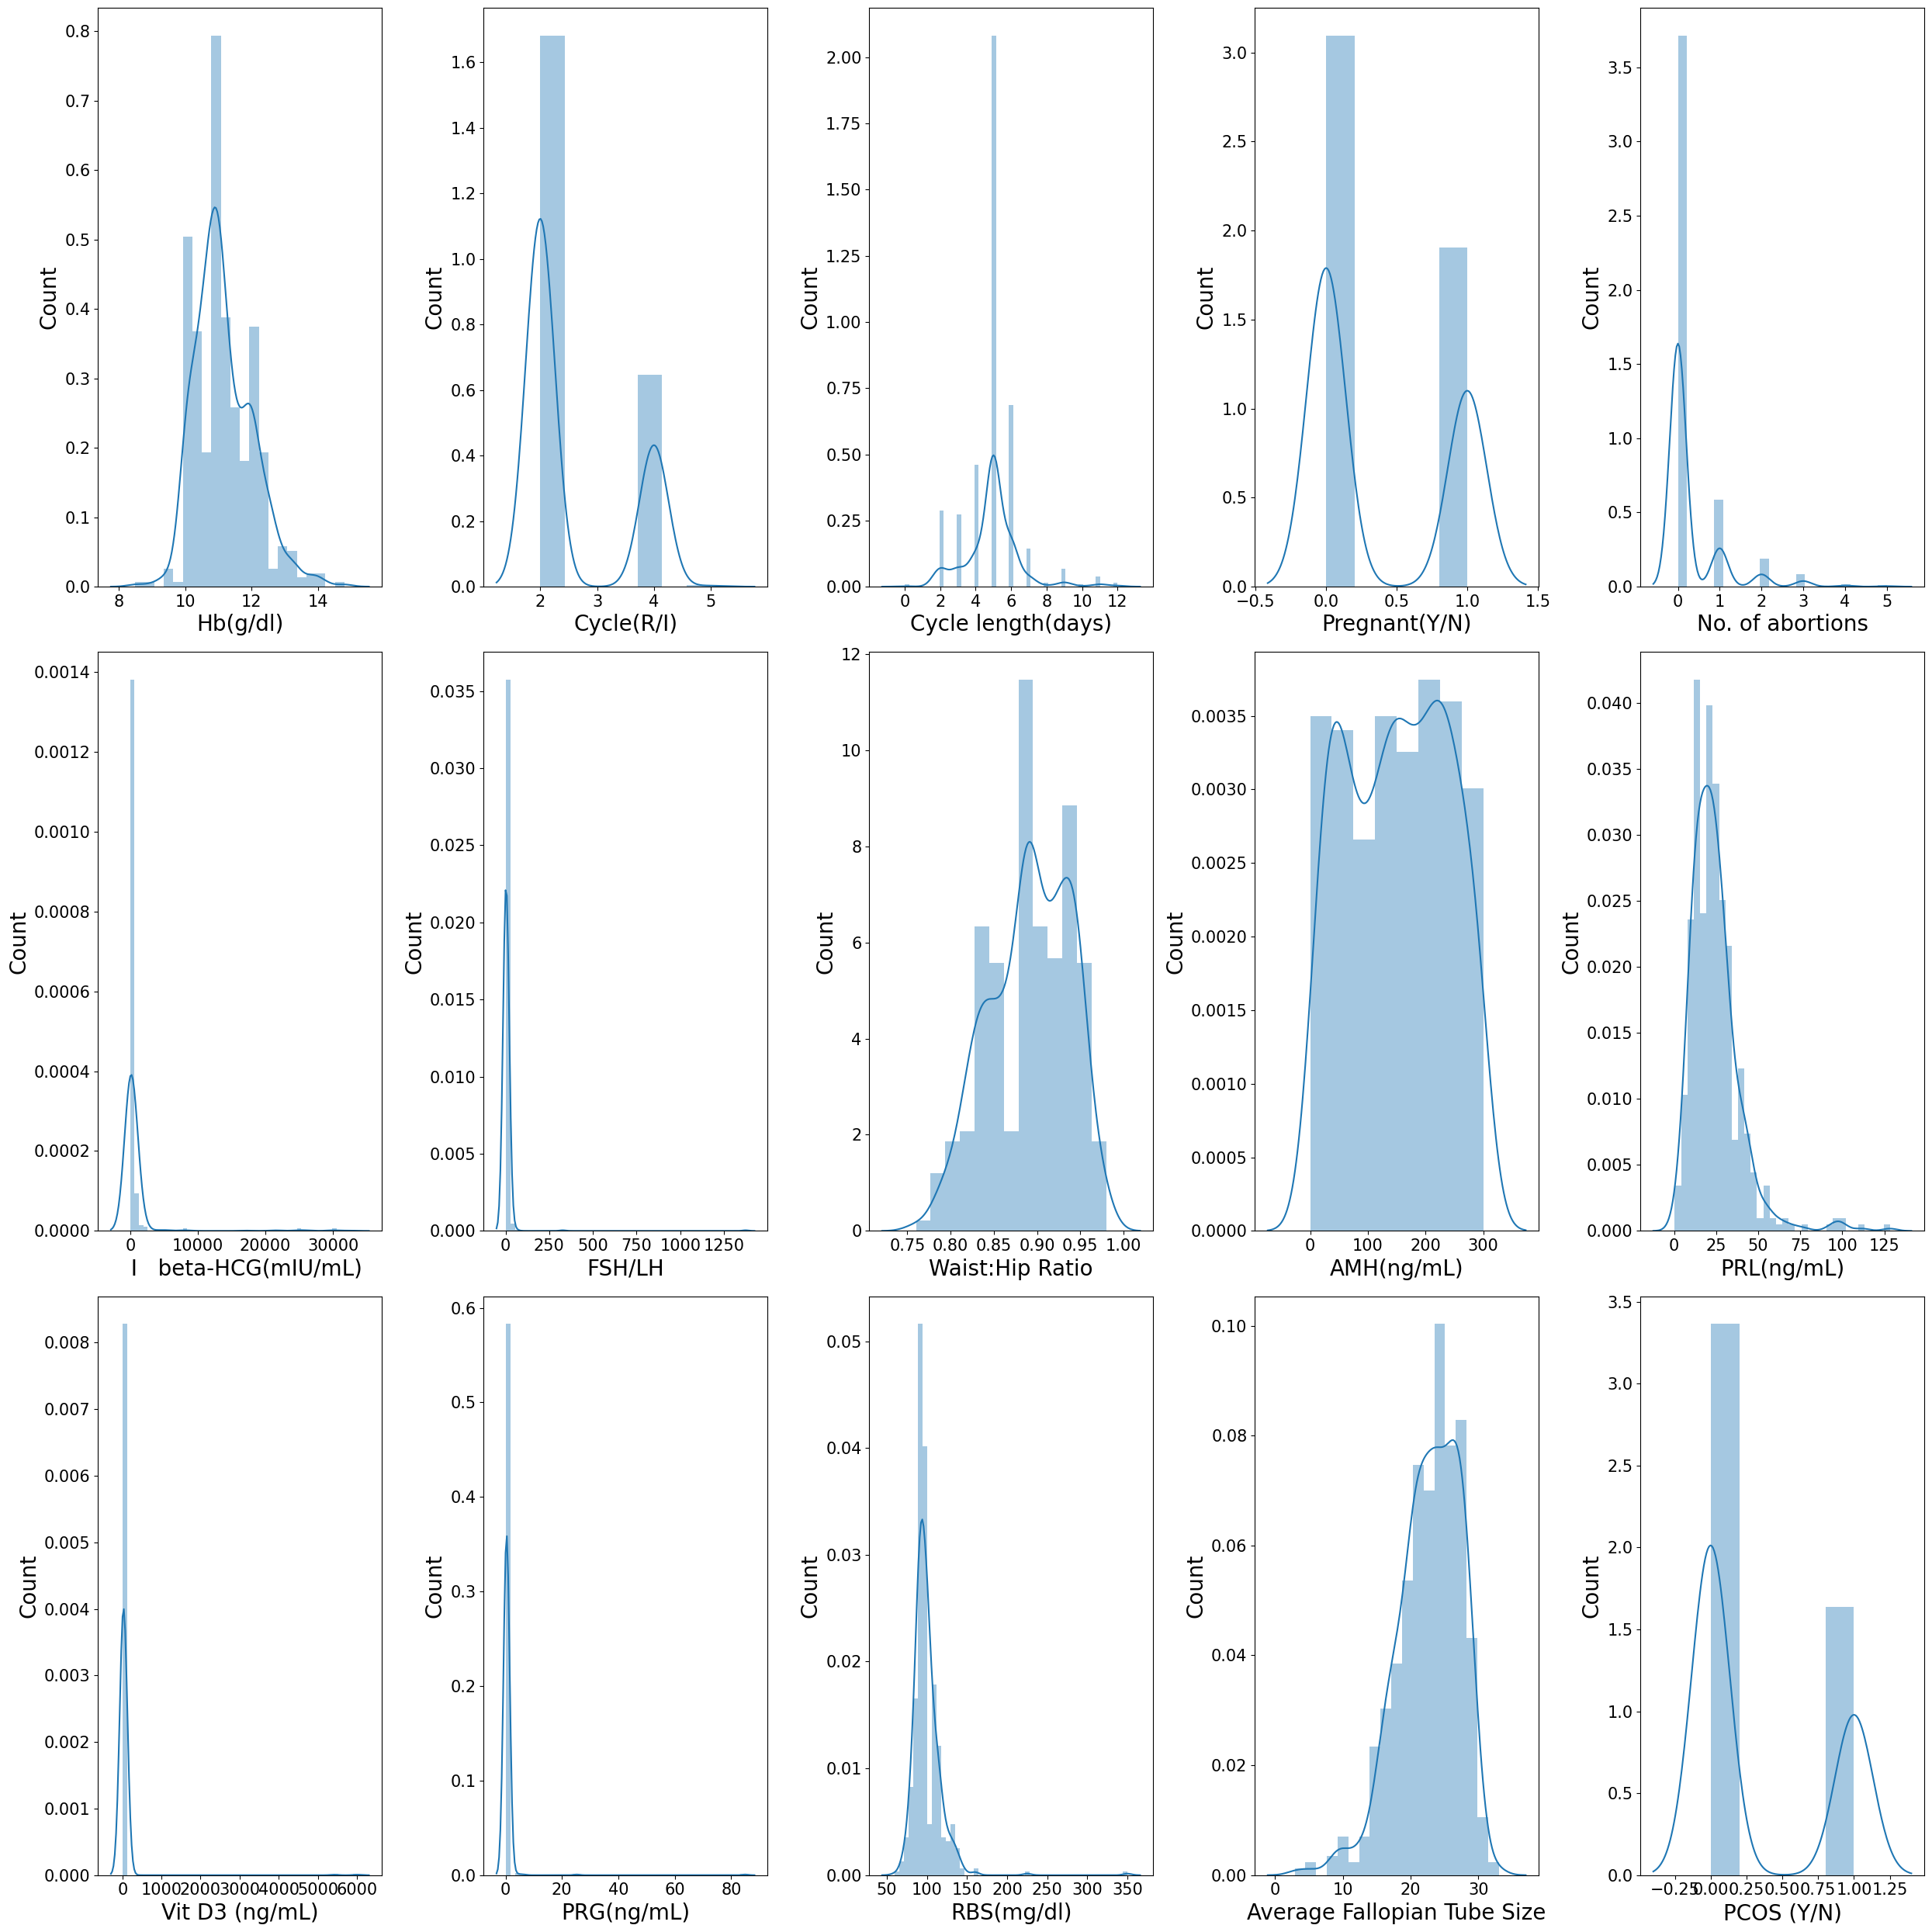

In [ ]:
plt.figure(figsize=(25, 25), facecolor='white')
plot=1
for i in df2.columns:
    if plot<=15:
        plt.subplot(3,5,plot)
        sns.distplot(df2[i])
        plt.xlabel(i, fontsize=20)
        plt.ylabel('Count', fontsize=20)  # Assuming ylabel is 'Count' for all
        plt.xticks(fontsize=15)
        plt.yticks(fontsize=15)
    plot+=1
plt.tight_layout()
plt.show()

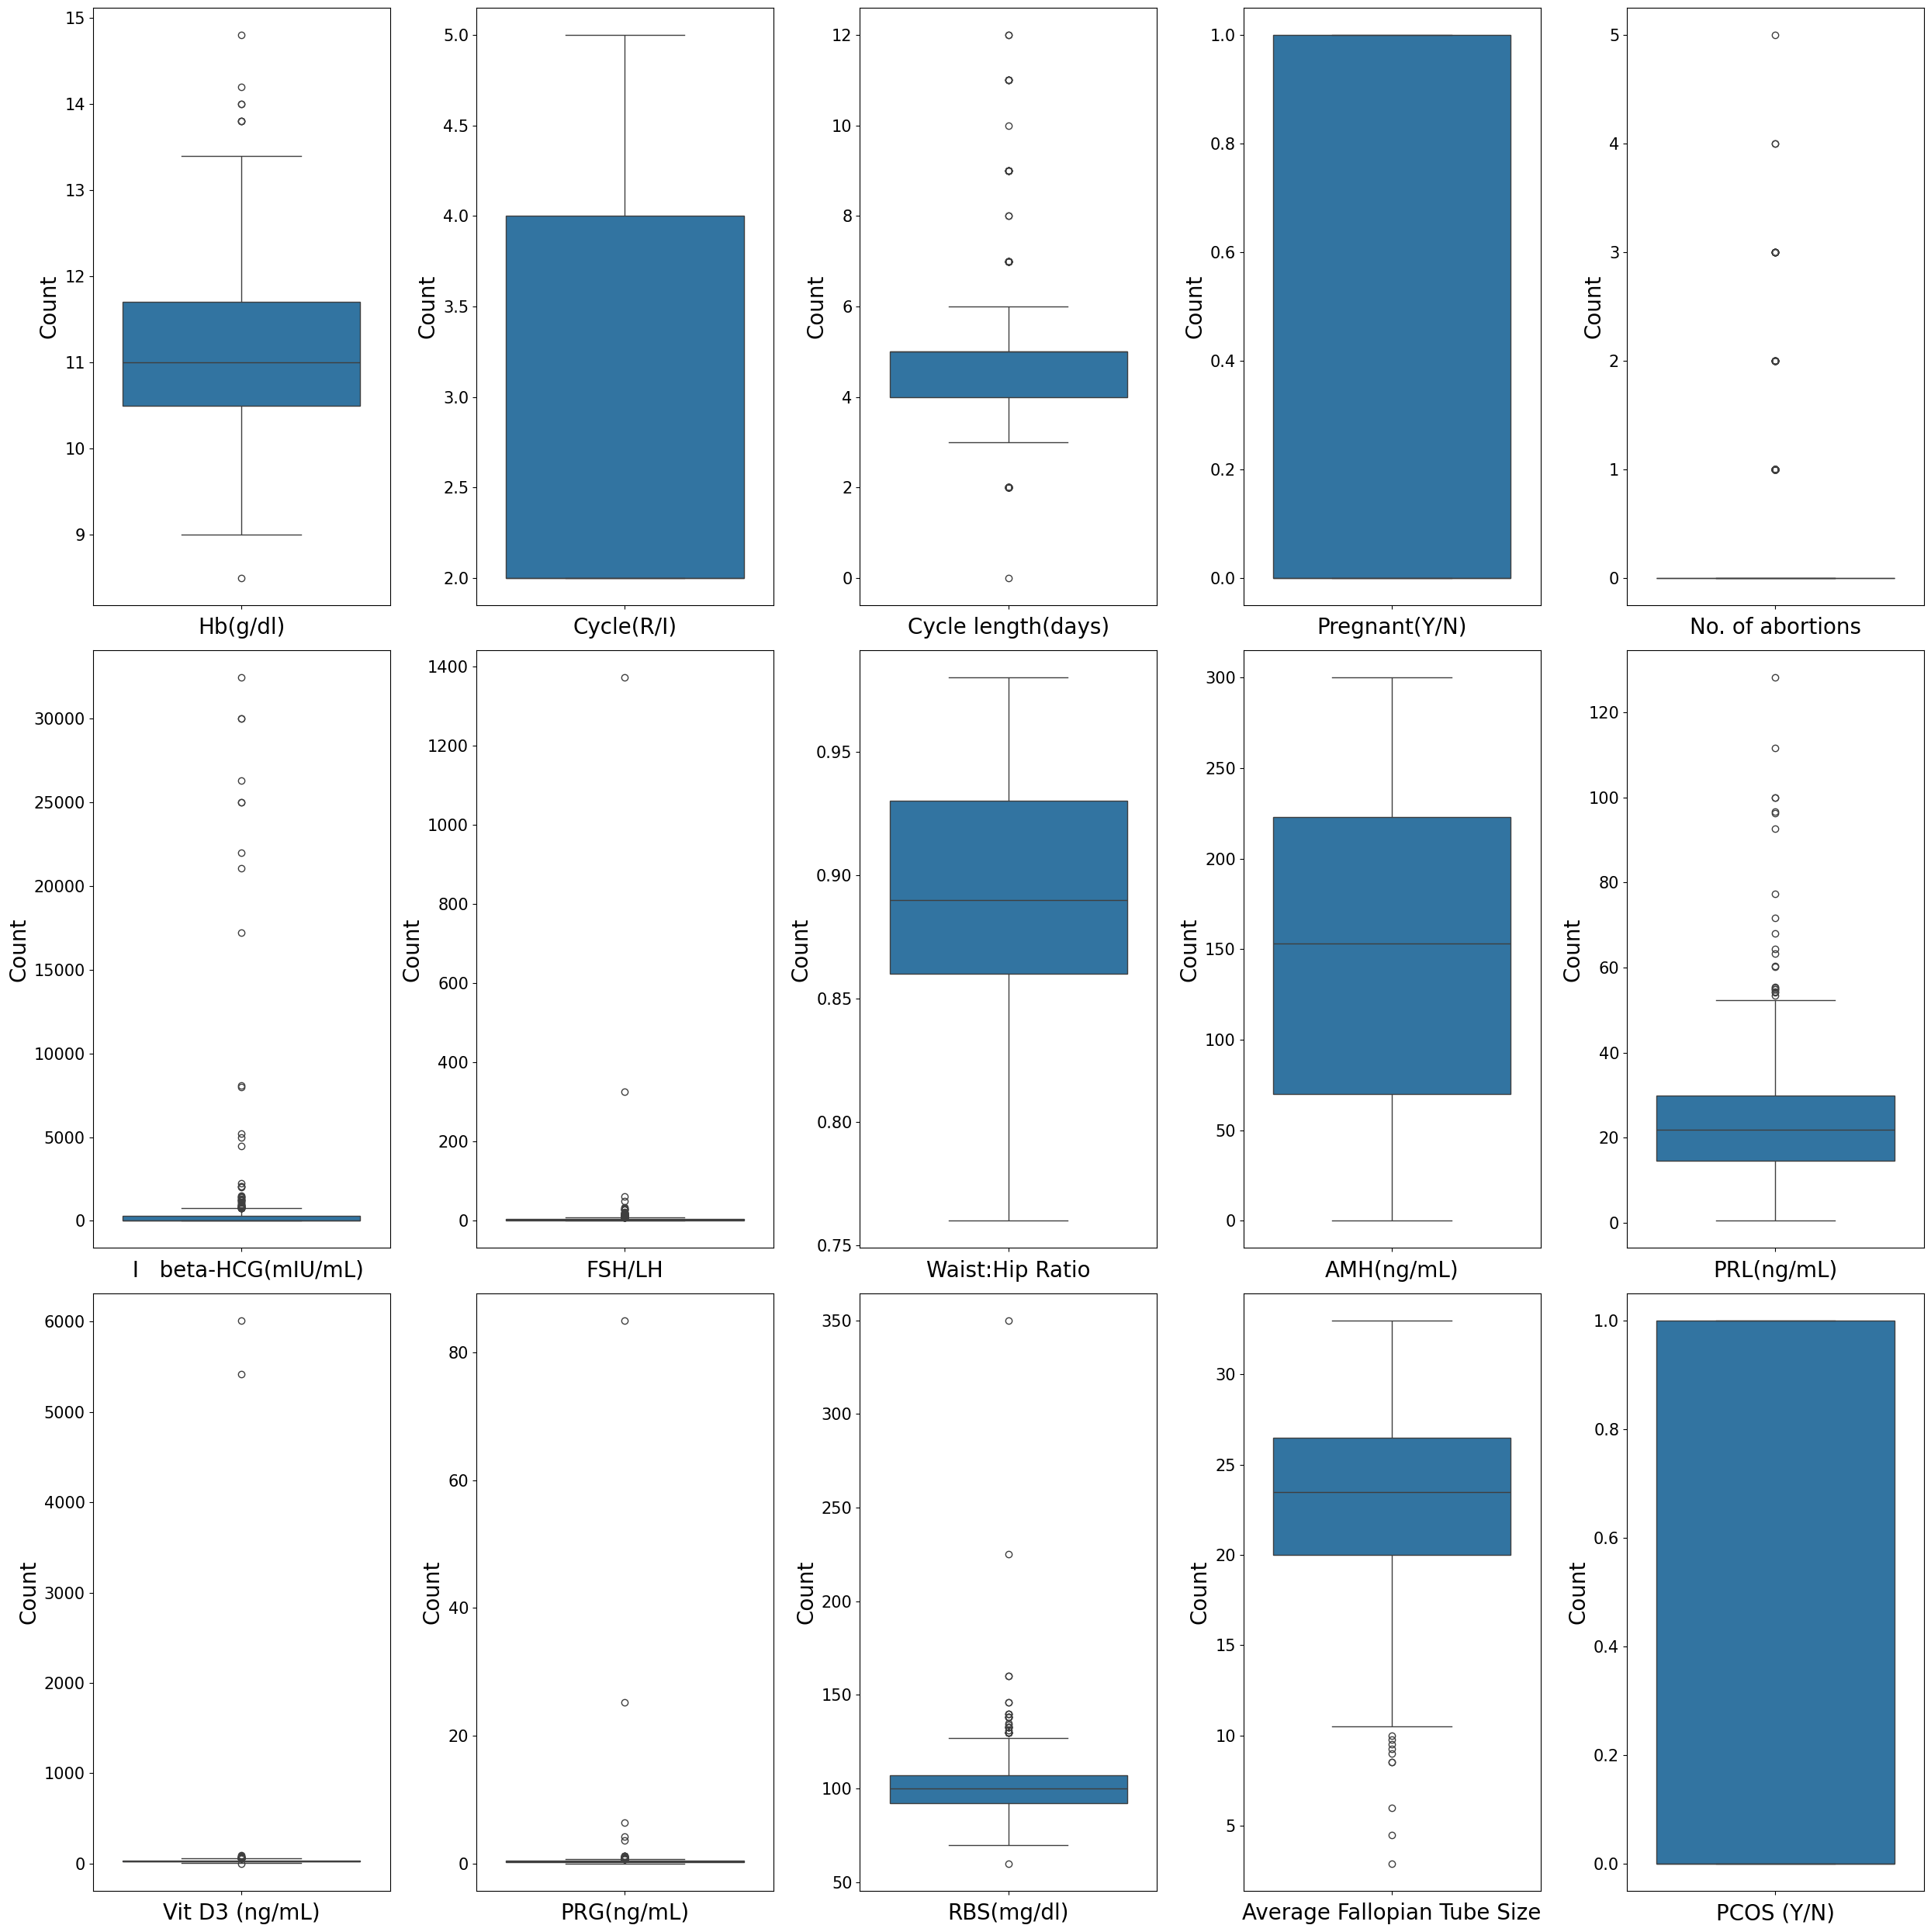

In [ ]:
plt.figure(figsize=(25, 25), facecolor='white')
plot=1
for i in df2.columns:
    if plot<=15:
        plt.subplot(3,5,plot)
        sns.boxplot(df2[i])
        plt.xlabel(i, fontsize=20)
        plt.ylabel('Count', fontsize=20)  # Assuming ylabel is 'Count' for all
        plt.xticks(fontsize=15)
        plt.yticks(fontsize=15)
    plot+=1
plt.tight_layout()
plt.show()

<Axes: >

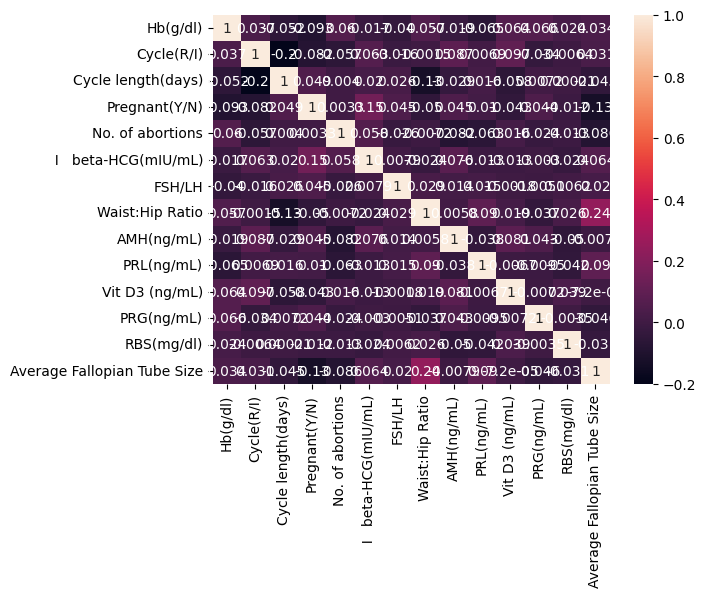

In [ ]:
sns.heatmap(df2.drop('PCOS (Y/N)',axis=1).corr(),annot= True)

In [ ]:
df2.rename(columns={'Hb(g/dl)':'Hb','Cycle length(days)':'cl','  I   beta-HCG(mIU/mL)':'Beta_HCG','FSH/LH':'FSH_LH','Average Fallopian Tube Size':'Fallopian_tube','Vit D3 (ng/mL)':'Vit_D','PRG(ng/mL)':'PRG','RBS(mg/dl)':'RBS','PRL(ng/mL)':'PRL'},inplace=True)

In [ ]:
df2_PCOS= df2['PCOS (Y/N)']

In [ ]:
df2_PCOS

,PCOS (Y/N)
0,0
1,0
2,1
3,0
4,0
...,...
536,0
537,0
538,0
539,0


In [ ]:
df2.drop('PCOS (Y/N)',axis=1, inplace = True)

In [ ]:
df2.loc[(df2['Hb']<8.71) & (df2['Hb']>13.48),'Hb']= np.median(df2.Hb)

In [ ]:
df2.loc[(df2['cl']>6.5) & (df2['cl']<2.5),'cl']=np.median(df2.cl)

In [ ]:
df2.loc[df2['Beta_HCG']>729.315,'Beta_HCG']=np.median(df2.Beta_HCG)

In [ ]:
df2

,Hb,Cycle(R/I),cl,Pregnant(Y/N),No. of abortions,Beta_HCG,FSH_LH,Waist:Hip Ratio,AMH(ng/mL),PRL,Vit_D,PRG,RBS,Fallopian_tube
0,10.48,2,5,0,0,1.99,2.16,0.83,124,45.16,17.1,0.57,92.0,27.0
1,11.70,2,5,1,0,60.80,6.17,0.84,49,20.09,61.3,0.97,92.0,22.0
2,11.80,2,5,1,0,494.08,6.30,0.90,266,10.52,49.7,0.36,84.0,28.0
3,12.00,2,5,0,0,1.99,3.42,0.86,41,36.90,33.4,0.36,76.0,22.0
4,10.00,2,5,1,0,20.00,4.42,0.81,133,30.09,43.8,0.38,84.0,23.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
536,11.00,2,5,0,1,1.99,5.56,0.93,59,5.30,36.6,0.25,92.0,22.5
537,10.80,2,5,1,1,80.13,1.79,0.94,243,21.09,23.0,0.25,108.0,28.0
538,10.80,2,6,0,0,1.99,4.30,0.93,198,96.41,22.5,0.25,92.0,22.5
539,12.00,4,2,0,0,292.92,1.02,0.93,234,38.89,22.4,0.25,115.0,26.0


In [ ]:
df2.loc[df2['FSH_LH']>12.64,'FSH_LH']=np.median(df2.FSH_LH)